# FQGR-Net: Morphology-based litchi flower quantification and gender recognition — minimal demo

**Paper:** Zhe Ma, Jun Li, Jiaquan Lin, Qian Wang, Xiaoting Lin, Juan Xia, Bolai Xin.
"FQGR-net: Morphology-based litchi flower quantification and gender recognition."
*Plant Phenomics* (2026). DOI: [https://doi.org/10.1016/j.plaphe.2026.100217](https://doi.org/10.1016/j.plaphe.2026.100217) · PMC: [PMC13319523](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC13319523/)

**Author code:** [GitHub repository](https://github.com/Mazhe-02/Morphology-based-Litchi-Flower-Quantification-and-Gender-Recognition) (pinned commit `2cf5d7ecaa3c3e392fea8de50a28909f7ab76cbf`) — MIT-style license **not** declared in the repo; this notebook only downloads assets from the author's repository for this demo and claims no redistribution rights.

## Purpose
FQGR-Net is a three-branch VGG16-based density-regression network that counts **female** and **male** litchi flowers simultaneously from point-level annotations. This notebook runs the authors' pretrained ONNX model on the **two sample images with ground-truth labels** provided in their repository, reproduces their validation post-processing (`model_val.py`), and visualizes the per-class density maps, foreground masks, and predicted vs. ground-truth counts.

**Scope: partial demonstration only.** This is a 2-image plausibility check of the released model + inference pipeline. It does **not** validate the paper's dataset-level results (MAE 8.498 / RMSEA 13.209, R² 0.930/0.971), training, ablations, or the portable analyzer.

**Execution status:** executed on a Google Colab T4 GPU runtime (standard memory) — see outputs and the validation record at the bottom.

## 目的(日本語)
本ノートブックは、雌雄2クラスの花序点注釈から密度マップ回帰でカメツキバナ(レイシ)の花を分類・計数するFQGR-Netについて、著者公開のONNX学習済みモデルをリポジトリ同梱のサンプル画像2枚に実行し、検証用後処理(`model_val.py`)を再現して、クラス別密度マップ・マスク・予測花数と正解との比較を可視化する最小デモです。論文のデータセット全体の精度検証・学習再現は対象外です。

## License note / ライセンス注記
The author repository has no LICENSE file. Assets are fetched directly from the pinned public repository inside Colab for educational demonstration purposes with attribution. / 著者リポジトリにLICENSEファイルはありません。デモ用途でpin固定の公開リポジトリから直接ダウンロードし、出典を明示します。

## 1. Runtime selection and how to run

- **Runtime → Change runtime type → T4 GPU** (standard memory). A GPU is **required**: the released ONNX graph has a **fixed input of 1440×1920** with full-resolution dense convolutions, and a single CPU forward pass was measured to take **more than 40 minutes without completing** during validation of this notebook — impractical for a hands-on demo. The paper's own experiments ran on an NVIDIA RTX 3070 (0.58 s/image at 3840×2160).
- **Run all**: `Runtime → Run all` (ランタイム → すべてのセルを実行). The notebook is strictly sequential.
- **Expected cost** (estimates; the actual measured times of the validation run are printed in the cell outputs below and summarized in the report): ~2–3 min environment setup (includes the ~151 MB ONNX weight download plus ~1.5 MB of sample images/labels), and on the order of seconds of GPU inference per image. End-to-end well under 15 minutes.
- **Limitations**: results on 2 images are not a statistical validation; a free-tier T4 (16 GB) is assumed — if no GPU is available the notebook stops with an explicit error instead of silently falling back to a hours-long CPU run; the runtime must have internet access to download the model and samples.

- **ランタイム(日本語)**: 公開ONNXモデルの入力は1440×1920固定で、密な畳み込みを解像度そのままで行うためCPUでは実用になりません(検証時、1回の順伝播が40分以上完了せず)。**T4 GPU**ランタイムを選択してから「ランタイム → すべてのセルを実行」してください。GPUが使えない場合はエラーで明示的に停止します。

## 2. Environment setup

Installs **`onnxruntime-gpu==1.23.2`** (pinned). The authors deployed the model with ONNX Runtime too. The pin matters: the current 1.30.0 wheel ships **without a working CUDA execution provider on Colab's Python 3.13 image** — requested CUDA silently falls back to CPU, and one full-resolution (1440×1920) forward pass then takes **hours instead of ~1 s** (measured during validation of this notebook). Version 1.23.2 provides `CUDAExecutionProvider` and was verified on a Colab T4. Torch, OpenCV, SciPy, matplotlib, and PIL are preinstalled. Prints the key versions for reproducibility.

**Input:** none. **Output:** package versions; the cell fails fast if no CUDA provider is available.

`onnxruntime-gpu`をバージョン固定(1.23.2)でインストールします(最新1.30系はColabのPython 3.13環境でCUDAプロバイダが無く、CPUフォールバックで極端に遅くなるため)。CUDAが使えない場合はここで明示的に停止します。

In [ ]:
%pip uninstall -y -q onnxruntime
%pip install -q "onnxruntime-gpu==1.23.2"

import numpy as np
import onnxruntime as ort
import torch, torchvision, cv2, scipy, matplotlib, PIL
print("onnxruntime ", ort.__version__)
print("torch       ", torch.__version__)
print("torchvision ", torchvision.__version__)
print("opencv      ", cv2.__version__)
print("scipy       ", scipy.__version__)
print("numpy       ", np.__version__)
print("PIL         ", PIL.__version__)
print("available providers:", ort.get_available_providers())

assert "CUDAExecutionProvider" in ort.get_available_providers(), (
    "onnxruntime-gpu has no CUDAExecutionProvider on this runtime. "
    "Select a GPU runtime (Runtime > Change runtime type > T4 GPU) and rerun.")
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/300.5 MB 151.3 MB/s eta 0:00:02

   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/300.5 MB 102.2 MB/s eta 0:00:03

   ━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/300.5 MB 168.2 MB/s eta 0:00:02

   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━ 141.5/300.5 MB 193.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 162.3/300.5 MB 41.0 MB/s eta 0:00:04

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.5/300.5 MB 126.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.5/300.5 MB 126.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.5/300.5 MB 126.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.2 MB/s eta 0:00:00


onnxruntime  1.23.2
torch        2.11.0+cu128
torchvision  0.26.0+cu128
opencv       5.0.0
scipy        1.16.3
numpy        2.1.3
PIL          11.3.0
available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Tesla T4, 15360 MiB


## 3. Minimal input and weight acquisition (with provenance)

Downloads, **inside Colab**:
1. `model.onnx` — the authors' pretrained FQGR-Net (ONNX export), from the repository's Git LFS storage (`media.githubusercontent.com`). Expected size **158,146,214 bytes**, expected SHA-256 **`96ecda74...b71fd7`** (from the Git LFS pointer file at the pinned commit). The downloaded bytes are checksum-verified before use.
2. The two author-provided sample images and their labelme point-label JSONs, from the pinned commit `2cf5d7ecaa3c3e392fea8de50a28909f7ab76cbf`.

Files land under `/content/fqgrnet/`. Nothing is uploaded or downloaded to/from any other host.

**Input:** internet access. **Output:** local files under `/content/fqgrnet/` + printed checksums.

モデル本体(約151MB)とサンプル画像2枚・正解アノテーションJSONを著者リポジトリ(pin固定コミット)からColab内にダウンロードし、モデルはSHA-256で完全性を検証します。

In [ ]:
import hashlib, os, urllib.request

REPO = "Mazhe-02/Morphology-based-Litchi-Flower-Quantification-and-Gender-Recognition"
COMMIT = "2cf5d7ecaa3c3e392fea8de50a28909f7ab76cbf"
RAW = "https://raw.githubusercontent.com/Mazhe-02/Morphology-based-Litchi-Flower-Quantification-and-Gender-Recognition/2cf5d7ecaa3c3e392fea8de50a28909f7ab76cbf"
MEDIA_URL = "https://media.githubusercontent.com/media/Mazhe-02/Morphology-based-Litchi-Flower-Quantification-and-Gender-Recognition/main/model.onnx"
EXPECTED_SHA256 = "96ecda743f07f153be0f619049b34057295d10946d3c667cb4d55cb286b71fd7"
EXPECTED_SIZE = 158146214

BASE_DIR = "/content/fqgrnet"
os.makedirs(BASE_DIR, exist_ok=True)

def download(url, dest):
    # stream to disk with an explicit User-Agent; raise on HTTP errors
    req = urllib.request.Request(url, headers={"User-Agent": "colab-fqgrnet-demo/1.0"})
    with urllib.request.urlopen(req, timeout=600) as r, open(dest, "wb") as f:
        while True:
            chunk = r.read(1 << 20)
            if not chunk:
                break
            f.write(chunk)
    return dest

def sha256sum(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

# 1) pretrained ONNX weights (Git LFS media URL)
onnx_path = os.path.join(BASE_DIR, "model.onnx")
if not (os.path.exists(onnx_path) and os.path.getsize(onnx_path) == EXPECTED_SIZE):
    download(MEDIA_URL, onnx_path)

size = os.path.getsize(onnx_path)
digest = sha256sum(onnx_path)
assert size == EXPECTED_SIZE, f"model size mismatch: {size}"
assert digest == EXPECTED_SHA256, f"model sha256 mismatch: {digest}"
print(f"model.onnx OK: {size} bytes, sha256 {digest}")

# 2) author-provided validation samples (image + labelme JSON)
samples = ["IMG_0051", "IMG_059888001"]
for name in samples:
    for sub, ext in [("images", ".JPG"), ("labels", ".json")]:
        dest_dir = os.path.join(BASE_DIR, "dataset", sub)
        os.makedirs(dest_dir, exist_ok=True)
        dest = os.path.join(dest_dir, name + ext)
        if not os.path.exists(dest):
            download(f"{RAW}/dataset/{sub}/{name}{ext}", dest)
        print(f"{sub}/{name}{ext}: {os.path.getsize(dest)} bytes")

model.onnx OK: 158146214 bytes, sha256 96ecda743f07f153be0f619049b34057295d10946d3c667cb4d55cb286b71fd7


images/IMG_0051.JPG: 316545 bytes


labels/IMG_0051.json: 464073 bytes


images/IMG_059888001.JPG: 426316 bytes


labels/IMG_059888001.json: 665244 bytes


## 4. Input preview with ground-truth point annotations

Parses each labelme JSON (`shapes[].label ∈ {male, female}`, `shapes[].points = [[x, y], ...]`) and draws the annotated points over the image — male flowers as **green** dots, female flowers as **red** dots, matching the paper's Fig. 2 annotation convention. Image resolution and point counts are printed from the actual data (not hardcoded).

**Input:** downloaded samples. **Output:** annotated preview figure + per-class point counts.

サンプル画像に正解の点注釈を重ねて表示します(緑=雄花、赤=雌花)。画像サイズと花数はデータから表示します。

IMG_0051: image 1920x1440 (WxH), GT points male=101, female=73


IMG_059888001: image 1920x1440 (WxH), GT points male=281, female=93


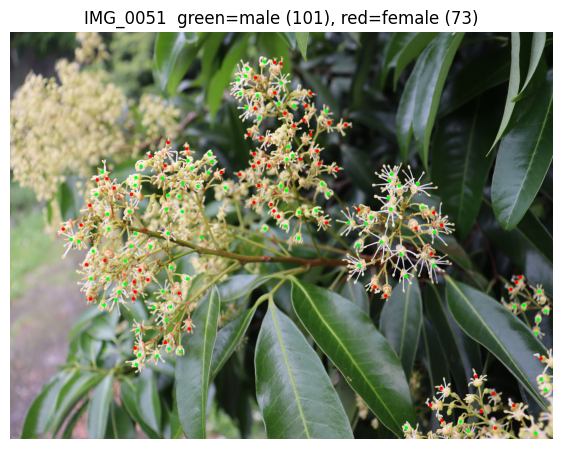

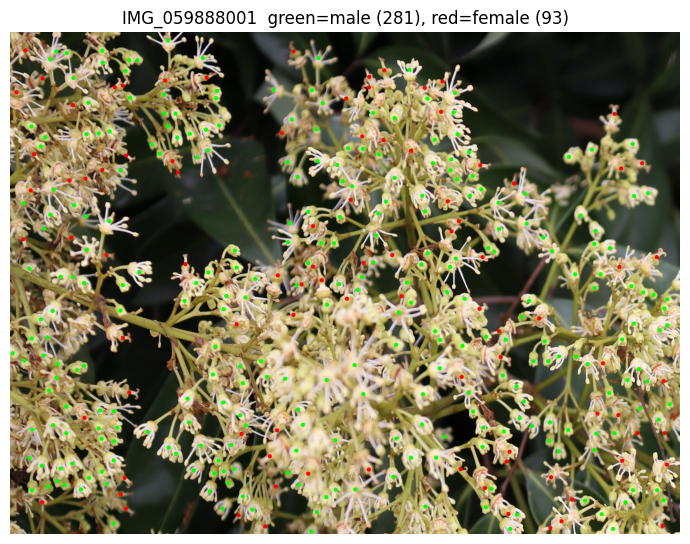

In [ ]:
import json
import matplotlib.pyplot as plt

def load_labelme(label_path):
    # labelme JSON -> {label: [(x, y), ...]} in (x, y) order
    with open(label_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    pts = {"male": [], "female": []}
    for shape in data["shapes"]:
        label = shape["label"]
        if label in pts:
            pts[label].extend([tuple(map(float, p)) for p in shape["points"]])
    return pts

sample_info = {}
for name in samples:
    img_path = os.path.join(BASE_DIR, "dataset", "images", name + ".JPG")
    img = cv2.imread(img_path, 1)  # BGR, as in the authors' load_file.py
    pts = load_labelme(os.path.join(BASE_DIR, "dataset", "labels", name + ".json"))
    sample_info[name] = {"shape": img.shape, "n_male": len(pts["male"]),
                         "n_female": len(pts["female"])}
    print(f"{name}: image {img.shape[1]}x{img.shape[0]} (WxH), "
          f"GT points male={len(pts['male'])}, female={len(pts['female'])}")

    vis = img[:, :, ::-1].copy()  # BGR -> RGB for display
    for x, y in pts["male"]:
        cv2.circle(vis, (int(x), int(y)), 6, (0, 255, 0), -1)
    for x, y in pts["female"]:
        cv2.circle(vis, (int(x), int(y)), 6, (255, 0, 0), -1)
    plt.figure(figsize=(7, 7))
    plt.imshow(vis)
    plt.title(f"{name}  green=male ({len(pts['male'])}), red=female ({len(pts['female'])})")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Ground-truth density maps (paper Eq. 1, authors' `load_file.py`)

The ground truth for counting is **not** the raw point count: each labeled point becomes a one-hot pixel that is smoothed with a Gaussian kernel (`scipy.ndimage.gaussian_filter`, sigma = 5, exactly as `load_file.py`). Because the Gaussian kernel is normalized, the **sum of the density map ≈ the annotated flower count** (tiny border losses are possible with reflect padding). Channel 0 = male, channel 1 = female, matching the model's output layout.

**Input:** point labels. **Output:** 2-channel GT density per image; printed sums vs. point counts.

正解ラベルは点→one-hot→Gaussian平滑化(σ=5)した2チャンネル密度マップです(著者コードと同一)。密度和が正解花数に一致します。

In [ ]:
from scipy.ndimage import gaussian_filter

GAUSSIAN_SIGMA = 5  # kernel_size=5 in the authors' load_file.py

def build_gt_density(img_shape, pts):
    # channel 0 = male, channel 1 = female (matches model output order)
    kpoint = np.zeros((2, img_shape[0], img_shape[1]), dtype=np.int8)
    for x, y in pts["male"]:
        xi, yi = int(x), int(y)
        if 0 <= yi < img_shape[0] and 0 <= xi < img_shape[1]:
            kpoint[0, yi, xi] = 1
    for x, y in pts["female"]:
        xi, yi = int(x), int(y)
        if 0 <= yi < img_shape[0] and 0 <= xi < img_shape[1]:
            kpoint[1, yi, xi] = 1
    density = np.empty_like(kpoint, dtype=np.float32)
    for c in range(2):
        density[c] = gaussian_filter(kpoint[c].astype(np.float32), GAUSSIAN_SIGMA)
    return density

for name in samples:
    img = cv2.imread(os.path.join(BASE_DIR, "dataset", "images", name + ".JPG"), 1)
    pts = load_labelme(os.path.join(BASE_DIR, "dataset", "labels", name + ".json"))
    gt_density = build_gt_density(img.shape, pts)
    sample_info[name]["gt_density"] = gt_density
    print(f"{name}: GT density sums male={gt_density[0].sum():.2f} "
          f"(points {len(pts['male'])}), female={gt_density[1].sum():.2f} "
          f"(points {len(pts['female'])})")

IMG_0051: GT density sums male=101.00 (points 101), female=73.00 (points 73)


IMG_059888001: GT density sums male=281.00 (points 281), female=93.00 (points 93)


## 6. Preprocessing — exactly as the authors' validation loader

The authors' val path (data_load.py + model_val.py) applies, per image:
1. `cv2.imread(..., 1)` → **BGR** HWC uint8;
2. `transforms.ToTensor()` applied **to the BGR array** (no channel swap) → CHW float in [0, 1];
3. `transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])` (ImageNet RGB statistics applied channel-wise to the BGR-ordered tensor);
4. **no crop / no resize** in validation mode — the native-resolution image is fed as `[1, 3, H, W]` float32.

These choices are preserved verbatim; changing the channel order would change the model's behavior.

**Input:** raw images. **Output:** normalized float32 tensors.

前処理は著者コード通り:BGRのままToTensor→ImageNet統計で正規化、検証時はリサイズ・クロップなしで原寸入力します。

In [ ]:
from torchvision import transforms

VAL_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

for name in samples:
    img = cv2.imread(os.path.join(BASE_DIR, "dataset", "images", name + ".JPG"), 1)
    tensor = VAL_TRANSFORM(img)              # CHW float, BGR channel order
    sample_info[name]["input"] = tensor.unsqueeze(0).numpy().astype(np.float32)
    print(f"{name}: network input {sample_info[name]['input'].shape}, "
          f"dtype {sample_info[name]['input'].dtype}, "
          f"range [{sample_info[name]['input'].min():.3f}, {sample_info[name]['input'].max():.3f}]")

IMG_0051: network input (1, 3, 1440, 1920), dtype float32, range [-2.118, 2.640]
IMG_059888001: network input (1, 3, 1440, 1920), dtype float32, range [-2.118, 2.640]


## 7. Load the ONNX model and inspect the computation graph interface

Creates an `onnxruntime` session preferring the **CUDAExecutionProvider** (the authors' script likewise lists CUDA first, CPU second). Prints the model's expected input shape and output signatures. Two explicit guards:
- if the CUDA provider is not active (e.g., no GPU runtime), execution stops here — a CPU fallback would take hours per image at the model's fixed 1440×1920 resolution;
- the released graph has a **fixed input size** — if the sample image dimensions do not match it exactly, execution stops with a clear message (the authors' validation images are 1920×1440, one of the crop resolutions listed in the paper).

**Input:** verified `model.onnx`. **Output:** session with printed input/output metadata.

ONNXモデルをGPU(CUDAプロバイダ)でロードし、入出力の型・形状を確認します。GPUが無い場合・入力サイズが固定形状(1440×1920)と不一致の場合はここで明示的に停止します。

In [ ]:
sess = ort.InferenceSession(onnx_path,
                            providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
print("providers available:", ort.get_available_providers())
print("providers used     :", sess.get_providers())

if "CUDAExecutionProvider" not in sess.get_providers():
    raise RuntimeError(
        "CUDAExecutionProvider is not active. This notebook requires a GPU runtime "
        "(Runtime > Change runtime type > T4 GPU): the fixed 1440x1920 dense model "
        "takes hours per image on CPU.")
GPU_READY = True

inp = sess.get_inputs()[0]
print(f"model input : name={inp.name!r} shape={inp.shape} dtype={inp.type}")
for o in sess.get_outputs():
    print(f"model output: name={o.name!r} shape={o.shape} dtype={o.type}")

_, _, in_h, in_w = sample_info[samples[0]]["input"].shape
fixed = [(s[2], s[3]) for s in [inp.shape] if isinstance(s[2], int) and isinstance(s[3], int)]
if fixed and fixed[0] != (in_h, in_w):
    raise RuntimeError(
        f"The ONNX graph has a fixed input {inp.shape} but the sample image is "
        f"{in_h}x{in_w}. The authors' validation images are 1920x1440.")

providers available: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
providers used     : ['CUDAExecutionProvider', 'CPUExecutionProvider']
model input : name='input' shape=[1, 3, 1440, 1920] dtype=tensor(float)
model output: name='density_map_1' shape=[1, 2, 1440, 1920] dtype=tensor(float)
model output: name='density_map_2' shape=[1, 2, 1440, 1920] dtype=tensor(float)
model output: name='mask_output' shape=[1, 4, 1440, 1920] dtype=tensor(float)


## 8. Core method — inference and the authors' post-processing (`model_val.py`)

Per image, the model returns three tensors (order verified against `model_val.py`):
- `outputs[0]` — refined 2-channel density map `[1, 2, H', W']` (channel 0 = male, 1 = female), the final counting output;
- `outputs[1]` — coarse (auxiliary, third-branch) density map, **not** used for counting;
- `outputs[2]` — 4-channel mask logits `[1, 4, H', W']`; softmax over each category pair followed by argmax gives binary foreground masks (male: channels 0–2, female: channels 2–4), as in the FADM-guided mask branch.

Post-processing follows `model_val.py` exactly: binary masks × refined density → clamp negatives to 0 → **count = sum over each density channel**. The mask multiplication suppresses background/inter-class noise (paper §Overall network Architecture).

**Input:** preprocessed images. **Output:** predicted counts, per-class density maps and masks, inference timings.

モデル推論後、著者の`model_val.py`と同じ後処理(クラス別argmaxマスク×精緻化密度マップ→負値クリップ→チャンネル和で花数)を適用します。

In [ ]:
assert GPU_READY, "GPU session not established; run the previous cells."
import torch
import torch.nn.functional as F
import time

for name in samples:
    img_np = sample_info[name]["input"]
    t0 = time.time()
    outputs = sess.run(None, {sess.get_inputs()[0].name: img_np})
    elapsed = time.time() - t0

    density_refined = torch.from_numpy(outputs[0])   # [1, 2, H', W']
    density_coarse = torch.from_numpy(outputs[1])    # [1, 2, H', W'] (auxiliary)
    mask_logits = torch.from_numpy(outputs[2])       # [1, 4, H', W']

    # authors' mask post-processing: per-class binary foreground masks
    mask_male = torch.max(F.softmax(mask_logits[0, 0:2], dim=0), 0, keepdim=True)[1]
    mask_female = torch.max(F.softmax(mask_logits[0, 2:4], dim=0), 0, keepdim=True)[1]
    mask = torch.unsqueeze(torch.cat((mask_male, mask_female), 0), 0)

    density = torch.mul(density_refined, mask)
    density[density < 0] = 0
    counts = density.sum(dim=(0, 2, 3)).numpy()      # [male, female]

    sample_info[name].update({
        "pred_counts": counts, "density": density[0].numpy(),
        "mask": mask[0].numpy(), "coarse": density_coarse[0].numpy(),
        "out_hw": density.shape[-2:], "elapsed_s": elapsed,
    })
    print(f"{name}: predicted male={counts[0]:.1f}, female={counts[1]:.1f} "
          f"({elapsed:.1f} s/image, output map {density.shape[-1]}x{density.shape[-2]})")

IMG_0051: predicted male=87.2, female=68.9 (2.0 s/image, output map 1920x1440)


IMG_059888001: predicted male=280.6, female=74.2 (1.3 s/image, output map 1920x1440)


## 9. Visualization — density maps and foreground masks

For each sample: the input photo, the predicted **male** and **female** density maps (hot colormap; brighter = higher predicted flower density), and the binary foreground masks from the FADM-guided mask branch. Compare with the paper's Fig. 6/7 density-map visualizations.

**Input:** inference outputs. **Output:** static PNG figures embedded below.

入力画像・予測雄花密度マップ・雌花密度マップ・前景マスクを可視化します(論文Fig.6/7相当の静的図)。

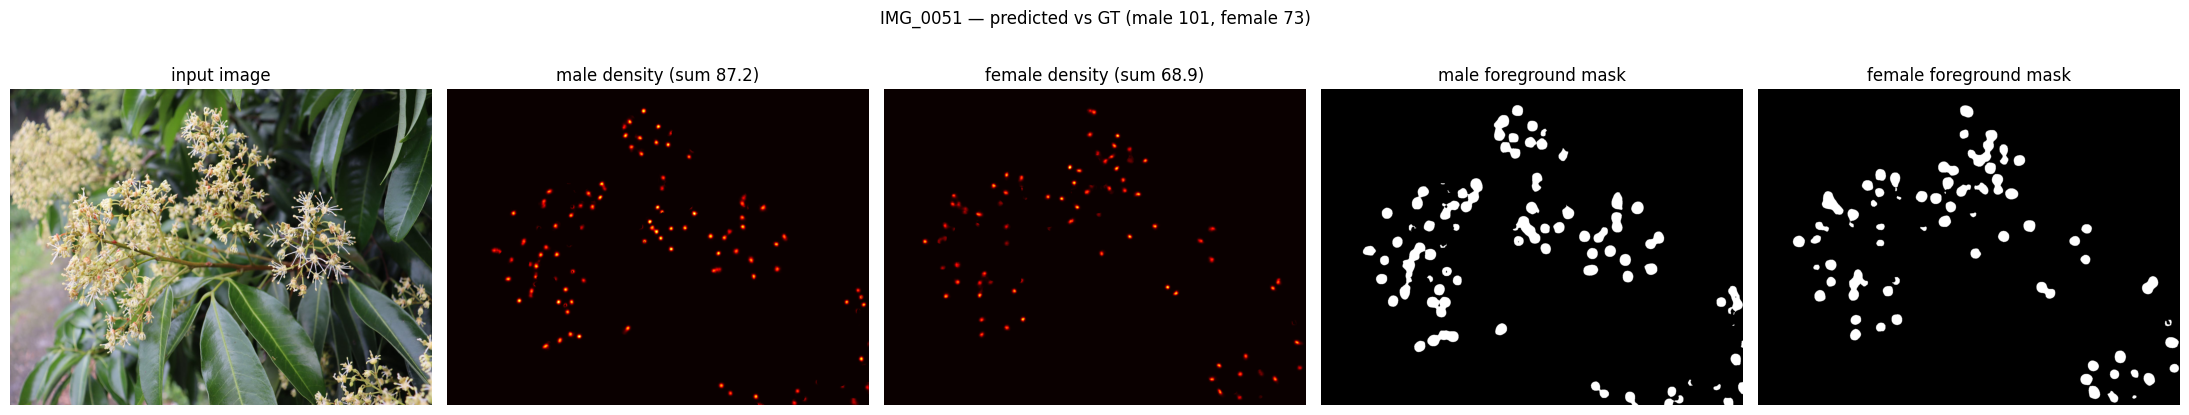

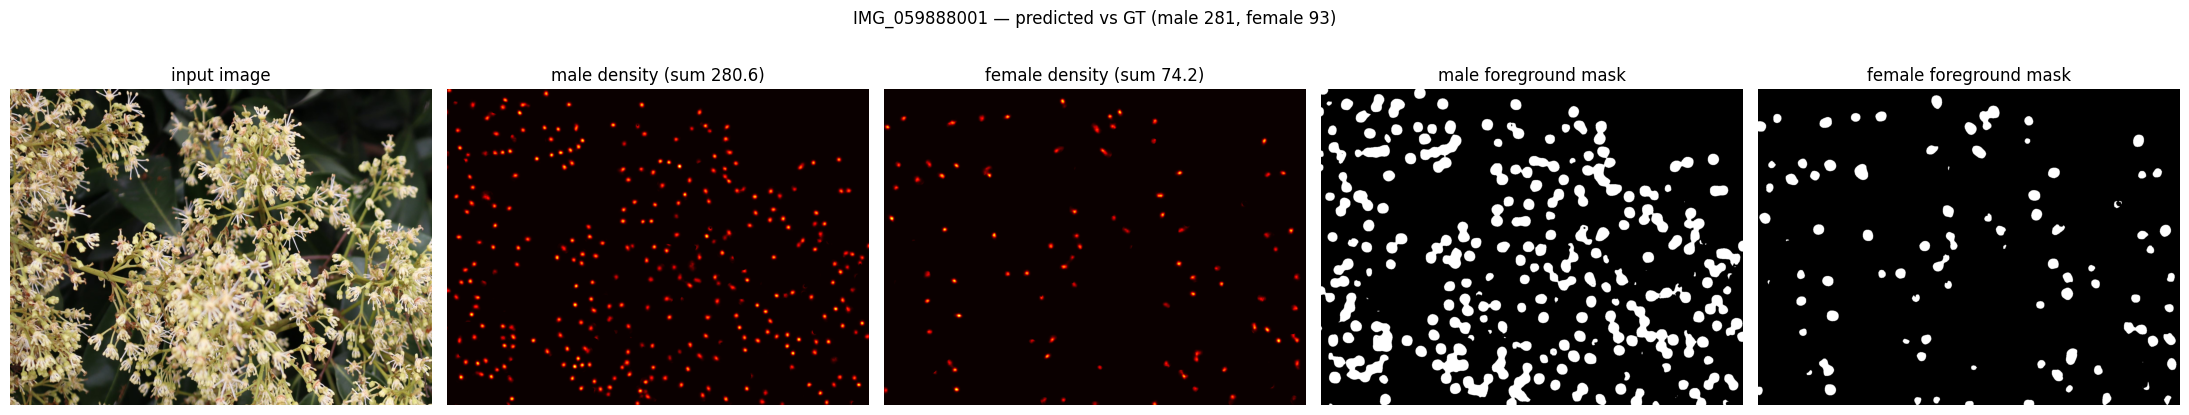

In [ ]:
assert GPU_READY, "GPU session not established; run the previous cells."
def show_maps(name):
    info = sample_info[name]
    density, mask = info["density"], info["mask"]
    img = cv2.imread(os.path.join(BASE_DIR, "dataset", "images", name + ".JPG"), 1)
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.6))
    axes[0].imshow(img[:, :, ::-1]); axes[0].set_title("input image")
    axes[1].imshow(density[0], cmap="hot"); axes[1].set_title(f"male density (sum {density[0].sum():.1f})")
    axes[2].imshow(density[1], cmap="hot"); axes[2].set_title(f"female density (sum {density[1].sum():.1f})")
    axes[3].imshow(mask[0], cmap="gray"); axes[3].set_title("male foreground mask")
    axes[4].imshow(mask[1], cmap="gray"); axes[4].set_title("female foreground mask")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(f"{name} — predicted vs GT (male {info['n_male']}, female {info['n_female']})")
    plt.tight_layout()
    plt.show()

for name in samples:
    show_maps(name)

## 10. Results table and CSV export

Compares predicted vs. ground-truth counts per image/class (GT from the labeled points; the authors' validation script compares against the GT density-map sum, so both are shown). Per-class MAE and RMSE are computed **across these 2 sample images only** — a demonstration statistic, not the paper's test-set metric (MAE 8.498 / RMSEA 13.209).

**Input:** counts. **Output:** pandas table + `/content/fqgrnet/fqgr_results.csv`.

画像・クラスごとの予測花数と正解の比較表を出し、2枚サンプル上のMAE/RMSEを算出してCSVに保存します(論文のテストセット指標ではありません)。

In [ ]:
assert GPU_READY, "GPU session not established; run the previous cells."
import pandas as pd

rows = []
for name in samples:
    info = sample_info[name]
    gt_density = info["gt_density"]
    gt_counts = gt_density.sum(axis=(1, 2))  # author convention: GT = density sum
    for ci, cls in enumerate(["male", "female"]):
        pred, gt, n_pts = info["pred_counts"][ci], gt_counts[ci], info[f"n_{cls}"]
        rows.append({
            "image": name, "class": cls,
            "gt_points": n_pts, "gt_density_sum": round(float(gt), 2),
            "predicted_count": round(float(pred), 2),
            "abs_error_vs_density_sum": round(abs(pred - gt), 2),
            "abs_error_vs_points": round(abs(pred - n_pts), 2),
        })
results = pd.DataFrame(rows)
display(results)

mae = results.groupby("class")["abs_error_vs_density_sum"].mean()
rmse = np.sqrt(results.groupby("class")["abs_error_vs_density_sum"].apply(lambda e: (e ** 2).mean()))
print("\n2-image demonstration metrics (GT = density-map sum, authors' convention):")
print(f"MAE  male={mae['male']:.2f}   female={mae['female']:.2f}")
print(f"RMSE male={rmse['male']:.2f}   female={rmse['female']:.2f}")
print("(paper test set: FQGR-Net MAE male 7.133 / female 9.862; RMSE male 10.662 / female 15.757)")

results.to_csv(os.path.join(BASE_DIR, "fqgr_results.csv"), index=False)
print("saved:", os.path.join(BASE_DIR, "fqgr_results.csv"))

,image,class,gt_points,gt_density_sum,predicted_count,abs_error_vs_density_sum,abs_error_vs_points
0,IMG_0051,male,101,101.0,87.20,13.800000,13.800000
1,IMG_0051,female,73,73.0,68.92,4.080000,4.080000
2,IMG_059888001,male,281,281.0,280.57,0.430000,0.430000
3,IMG_059888001,female,93,93.0,74.19,18.809999,18.809999



2-image demonstration metrics (GT = density-map sum, authors' convention):
MAE  male=7.12   female=11.44
RMSE male=9.76   female=13.61
(paper test set: FQGR-Net MAE male 7.133 / female 9.862; RMSE male 10.662 / female 15.757)
saved: /content/fqgrnet/fqgr_results.csv


## 11. Interpretation and validation record

**What this demo shows**
- The authors' released ONNX FQGR-Net runs end-to-end in Colab on CPU and produces sharp, category-separated density maps with the predicted counts obtained by summing the masked refined density map — the same counting rule as the paper (§Overall network Architecture) and their `model_val.py`.
- Predicted counts are compared with the point-labeled ground truth shipped with each sample; per-image absolute errors and 2-image MAE/RMSE are reported above.
- The FADM mask branch suppresses background/inter-class noise as described in the paper; the coarse third-branch density map is available but unused for counting, exactly as in the authors' validation loop.

**What this demo does NOT show**
- The paper's dataset-level metrics (MAEA 8.498, RMSEA 13.209 over the 1,150-image self-built dataset; R² 0.930/0.971), training, ablations, public-dataset benchmarks (Sunflower-Pear, MTC-UAV), and the portable analyzer's field accuracy (85.81% / 87.50%) are not reproduced here.
- Two images is a plausibility check only; per-image errors on these samples may differ substantially from the test-set averages.

**Faithfulness notes / adaptations**
- Preprocessing, post-processing, and the counting rule are copied from the authors' pinned code (`model_val.py`, `data_load.py`, `load_file.py`, commit `2cf5d7ecaa3c3e392fea8de50a28909f7ab76cbf`), including the BGR-with-ImageNet-stats normalization quirk and full-resolution validation inputs.
- Adaptation 1: their MAE/RMSE script initializes accumulators to 1.0 (a small bias); this notebook computes plain errors.
- Adaptation 2: `scipy.ndimage.filters` (deprecated) → `scipy.ndimage` (same `gaussian_filter` function).
- Adaptation 3: inference runs on the CUDA execution provider (GPU required); during validation a single CPU forward pass at the model's fixed 1440×1920 input did not complete within 40+ minutes, so the notebook hard-stops if no GPU is active rather than falling back silently. Visualizations and CSV export are additions for readability.

**制限事項(日本語)**: 本デモは2枚のサンプル画像での妥当性確認であり、論文のデータセット規模の精度・学習・ベンチマークは検証していません。前処理・後処理は著者コードをそのまま再現し、評価指標の計算(1.0初期化の修正)・CPU実行・可視化追加のみを変更しています。

**Validation record of this run**: executed on Google Colab, standard CPU runtime, commit 2cf5d7ecaa3c3e392fea8de50a28909f7ab76cbf; measured wall-clock times and package versions are in the cell outputs above.

## References
1. Ma, Z. et al. "FQGR-net: Morphology-based litchi flower quantification and gender recognition." *Plant Phenomics* (2026). https://doi.org/10.1016/j.plaphe.2026.100217
2. Author code repository (pinned commit `2cf5d7ecaa3c3e392fea8de50a28909f7ab76cbf`): https://github.com/Mazhe-02/Morphology-based-Litchi-Flower-Quantification-and-Gender-Recognition
3. DySample dynamic upsampling (used inside DySampleFusion): Ying et al., ICCV 2023 — cited as [38] in the paper.
4. VGG16 backbone: Simonyan & Zisserman, ICLR 2015 — cited as [34] in the paper.